# Helper Functions

## Load LLM Client

In [56]:
import os
import re
from datetime import datetime
import pandas as pd
from datetime import timedelta

# ========================================
# CHOOSE YOUR PROVIDER AND PASTE API KEY
# ========================================
PROVIDER = "gemini"  # Options: "claude" or "gemini"

CLAUDE_API_KEY = "YOUR_CLAUDE_KEY_HERE"  # Get from: https://console.anthropic.com/
GEMINI_API_KEY = os.environ["GEMINI_API_KEY"]  # Get from: https://aistudio.google.com/app/apikey

# ========================================

# Setup based on provider
if PROVIDER == "claude":
    import anthropic
    client = anthropic.Anthropic(api_key=CLAUDE_API_KEY)
    print("✅ Using Claude (Anthropic)")
    print("   Model: claude-3-haiku-20240307")
    
elif PROVIDER == "gemini":
    import google.generativeai as genai
    genai.configure(api_key=GEMINI_API_KEY)
    #client = genai.GenerativeModel('models/gemini-3.1-flash-lite-preview')
    client = genai.GenerativeModel('models/gemini-3-flash-preview')
    #client = genai.GenerativeModel('models/gemini-2.5-flash')
    print("✅ Using Gemini")
    print("   ⚠️  Note: Only 20 requests/day on free tier")


✅ Using Gemini
   ⚠️  Note: Only 20 requests/day on free tier


## Error Calculation

In [2]:
import numpy as np
import re
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_llm_forecast_48h(df, Turb_ID, base_day, output):
    """
    Evaluates a 48-hour (288 point) forecast.
    Always compares against Day base_day+14 and base_day+15.
    """

    # 1. Define 48-hour target window
    target_start = base_day + 14
    target_end = base_day + 15

    # 2. Extract actual data (chronological order)
    actual_data = df[
        (df['TurbID'] == Turb_ID) &
        (df['Day'] >= target_start) &
        (df['Day'] <= target_end)
    ]

    actual_values = (
        actual_data
        .sort_values(['Day', 'Tmstamp'])
        ['Patv']
        .dropna()
        .tolist()
    )

    # Parsing of LLM output
    try:
        predicted_values = [
            float(x) for x in re.findall(r"[-+]?\d*\.\d+|\d+", output)
        ]
    except Exception:
        print("Error: Could not parse LLM output.")
        return None

    # Check expected length (288 points)
    if len(predicted_values) != 288:
        print(f"Warning: Expected 288 predictions, got {len(predicted_values)}")

    if len(actual_values) != 288:
        print(f"Warning: Expected 288 actual points, got {len(actual_values)}")

    # Align lengths safely
    min_len = min(len(actual_values), len(predicted_values))

    if min_len == 0:
        print("Error: No overlapping forecast points.")
        return None

    y_true = actual_values[:min_len]
    y_pred = predicted_values[:min_len]

    # Metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    score = (mae + rmse) /2

    print(f"\n--- 48-Hour Evaluation (Days {target_start}-{target_end}) ---")
    print(f"Points used: {min_len}/288")
    print(f"MAE:  {mae:.2f} kW")
    print(f"RMSE: {rmse:.2f} kW")
    print(f"Score: {score:.2f} kW")

    return {
        "MAE": mae,
        "RMSE": rmse,
        "Score": score,
        "points_used": min_len
    }

## Plot Generation

In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def plot_llm_predictions_vs_ground_truth(
    data_df: pd.DataFrame,    # Pass the actual DataFrame here
    llm_responses,           # List of raw string responses from the LLM
    turb_id: int,
    forecast_day: int,
    horizon_days: int = 2,
    labels=None,
    title=None,
    clip=(0.0, 1500.0),
    hour_tick: float = 2.0,
    legend_alpha: float = 0.75,
    show=True,
):
    # --- 1. Handle Inputs ---
    if labels is None:
        labels = [f"LLM Prediction {i+1}" for i in range(len(llm_responses))]
    
    # --- 2. Ground Truth Extraction ---
    expected_len = 144 * horizon_days
    target_days = list(range(forecast_day, forecast_day + horizon_days))
    
    gt = data_df[(data_df["TurbID"] == turb_id) & (data_df["Day"].isin(target_days))].copy()
    if gt.empty:
        raise ValueError(f"No ground-truth found for TurbID {turb_id} on days {target_days}")

    gt = gt.sort_values(["Day", "Tmstamp"]) if "Tmstamp" in gt.columns else gt.sort_values(["Day"])
    
    y_true = gt["Patv"].to_numpy(dtype=float)
    if len(y_true) < expected_len:
         # Pad or truncate if data is slightly off, but warn user
         print(f"Warning: GT length {len(y_true)} vs expected {expected_len}")
    
    y_true = np.clip(y_true[:expected_len], clip[0], clip[1])

    # --- 3. Setup Plot ---
    x_hours = np.arange(len(y_true)) / 6.0
    fig, ax = plt.subplots(figsize=(12.5, 5))
    ax.plot(x_hours, y_true, linewidth=2.0, label="Ground truth", color='tab:blue')

    # --- 4. Parse and Plot LLM Responses ---
    for raw_response, lab in zip(llm_responses, labels):
        try:
            # Clean up potential markdown formatting
            clean_json = raw_response.replace("```json", "").replace("```", "").strip()
            data = json.loads(clean_json)
            y_pred = np.array(data["forecast"], dtype=float)
            
            if len(y_pred) != expected_len:
                print(f"Warning: {lab} returned {len(y_pred)} steps, expected {expected_len}")
            
            # Ensure length matches x_hours for plotting
            plot_len = min(len(y_pred), len(x_hours))
            y_pred_clipped = np.clip(y_pred[:plot_len], clip[0], clip[1])
            
            ax.plot(x_hours[:plot_len], y_pred_clipped, linewidth=1.5, linestyle="--", color="orange", label=lab)
            
        except Exception as e:
            print(f"Error parsing LLM response for {lab}: {e}")

    # --- 5. Formatting ---
    ax.set_xlim(0, 24 * horizon_days)
    ax.set_xticks(np.arange(0, (24 * horizon_days) + 1e-9, hour_tick))
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Patv (kW)")
    ax.grid(True, alpha=0.2)

    if title is None:
        title = f"TurbID={turb_id} | Day {forecast_day} | Horizon = 2 day(s)"
    ax.set_title(title)

    # Update this section in your plotting function
    ax.legend(
        loc="lower left",            # Anchors the legend to its bottom-left corner
        bbox_to_anchor=(0.02, 0.02), # Adds a small padding from the axes corner
        framealpha=legend_alpha,
        fontsize=10,
        borderpad=0.6,
        labelspacing=0.4,
        handlelength=2.2,
    )
    fig.tight_layout()
    
    if show:
        plt.show()
    return fig, ax

## Binning Data

In [65]:
def bin_turbine_data(df, n_bins=16, bin_cols=None):
    """
    Bins numeric columns in a dataframe into equal-width integer IDs [0, n_bins-1].
    """
    hist = df.copy()
    if bin_cols is None:
        excluded = {"TurbID", "Day", "Tmstamp"}
        bin_cols = [
            c for c in hist.columns 
            if (c not in excluded) and pd.api.types.is_numeric_dtype(hist[c])
        ]

    for c in bin_cols:
        x = pd.to_numeric(hist[c], errors="coerce")
        valid = x.dropna()
        if valid.empty:
            continue

        lo, hi = float(valid.min()), float(valid.max())
        
        if np.isclose(lo, hi):
            hist[c] = 0
            continue

        # Create equal-width bins
        edges = np.linspace(lo, hi, n_bins + 1)
        binned = pd.cut(
            x,
            bins=edges,
            labels=False,
            include_lowest=True,
            duplicates="drop",
        )
        hist[c] = binned.astype("Int64")
        
    return hist, bin_cols

## Open-Meteo Reanalysis Dataset (Weather Forecast Tool)

### (Could not find pure historical forecasts as such datasets are only kept for 5 years i.e. only has data from 2021-2026, while we needed 2020)

In [53]:
import openmeteo_requests
import pandas as pd
import requests_cache
import time
from retry_requests import retry

def get_openmeteo_wind_data(lat, lon, start_date, end_date):
    """
    Fetches 100m wind speed data from Open-Meteo Archive API.
    """
    # Setup the API client
    cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
    retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
    openmeteo = openmeteo_requests.Client(session=retry_session)

    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "wind_speed_100m",
        "timezone": "auto",
        "wind_speed_unit": "ms",
    }
    
    responses = openmeteo.weather_api(url, params=params)
    response = responses[0]

    # Process hourly data
    hourly = response.Hourly()
    hourly_wind_speed_100m = hourly.Variables(0).ValuesAsNumpy()

    hourly_data = {
        "timestamp": pd.date_range(
            start=pd.to_datetime(hourly.Time() + response.UtcOffsetSeconds(), unit="s", utc=True),
            end=pd.to_datetime(hourly.TimeEnd() + response.UtcOffsetSeconds(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly.Interval()),
            inclusive="left"
        ),
        "wind_speed_100m": hourly_wind_speed_100m
    }

    return pd.DataFrame(data=hourly_data)

# Baseline Prompt

In [ ]:
import pandas as pd

def call_llm_base(df, Turb_ID, base_day):
    turbine_data = df[df['TurbID'] == Turb_ID]
    # Drop rows where 'Wspd' (Wind Speed) is missing
    turbine_data = turbine_data.dropna(subset=['Wspd'])

    end_day = base_day + 13
    window_data = turbine_data[(turbine_data['Day'] >= base_day) & 
                               (turbine_data['Day'] <= end_day)].drop(columns=['TurbID'])

    data_str = window_data.to_csv(index=False, sep=',')

    prompt = f"""
You have been provided with 14 days of sensor data for one Wind Turbine, starting from day {base_day} to day {end_day}. 

Input Data (last 14 days):
{data_str}

Task: Predict the 'Patv' (Active Power) for the NEXT 48 hours (Day {end_day + 2}). Do not write code. Return only a list containing exactly 288 numerical values (144 per day), representing 10-minute intervals.
"""
    
    if PROVIDER == "claude":
        response = client.messages.create(
            model="claude-3-haiku-20240307",
            max_tokens=1024,
            messages=[{"role": "user", "content": prompt}]
        )
        return response.content[0].text
    else:  # gemini
        response = client.generate_content(prompt)
        return response.text

# Advanced Prompt

In [ ]:
def call_llm_advanced(df, Turb_ID, base_day, feature_cols):
    turbine_data = df[df['TurbID'] == Turb_ID]
    turbine_data = turbine_data.dropna(subset=['Wspd'])

    end_day = base_day + 13

    #required_cols = ['Day', 'Tmstamp'] + feature_cols

    window_data = turbine_data[
        (turbine_data['Day'] >= base_day) & 
        (turbine_data['Day'] <= end_day)
    ].copy()#[required_cols].copy()


    data_str = window_data.to_csv(index=False, sep=',')

    prompt = f"""
Context: You are an expert wind turbine power forecasting model.

You are given 14 days of historical SCADA data for ONE turbine.
The data is sampled every 10 minutes (144 rows per day).
Columns provided: {', '.join(window_data.columns.tolist())}

Input Data:
{data_str}

Your task:
Predict the Active Power (Patv, in kW) for the NEXT 48 HOURS
(288 time steps at 10-minute resolution).

Instructions:

Learn the wind-speed to power relationship from the historical data.
Power is roughly proportional to wind speed cubed at low speeds.
Power saturates near rated power (~1500 kW).
Power is near zero at very low wind speeds.

Capture daily cyclic patterns.
Do NOT copy the last day.
Do NOT output negative values.
Clip values to the realistic range [0, 1500].

OUTPUT FORMAT REQUIREMENTS (CRITICAL):

Return valid JSON in the following format:

{{
  "forecast": [f1, f2, f3, ..., f288]
}}

The list MUST contain exactly 288 numbers.
If the list contains more or fewer values, the answer is invalid.

No text outside the JSON.
No explanations.
No markdown formatting.
Only raw JSON.
"""

    if PROVIDER == "claude":
        response = client.messages.create(
            model="claude-3-haiku-20240307",
            max_tokens=1024,
            messages=[{"role": "user", "content": prompt}]
        )
        return response.content[0].text
    else:  # gemini
        response = client.generate_content(
            prompt
        )
        return response.text

## Running the Advanced Prompt

### Step 1: Load Data & Initialize Parameters

In [48]:
df = pd.read_csv('wtbdata_245days.csv')
df_era5 = pd.read_csv('gemini_input_era5.csv')
feature_sets = {
    "all_features": ["Wspd", "Wdir", "Etmp", "Itmp", "Ndir", 
                     "Pab1", "Pab2", "Pab3", "Prtv", "Patv"],
    "era5_features": ["Wspd", "Wdir", "Etmp", "Patv"]
}

In [49]:
# Select from Turbines ID 1 - 134
Turbine = 1

# Select from Days 1 - 231 (There are 245 days total, but we need to leave room for the 14-day input window and 2-day forecast horizon)
Data_Start_Day = 36

# Decide which features to use for the LLM forecast
Used_Columns = feature_sets["all_features"]

# Used when plotting to indicate forecast start day on x-axis
Forecast_Day = Data_Start_Day + 14

### Step 2: Forecast with LLM Call

In [50]:
advanced_output = call_llm_advanced(df, Turb_ID=Turbine, base_day=Data_Start_Day, feature_cols=Used_Columns)

### Step 3: Calculate MAE, RMSE, and Score and Plot Results

In [51]:
print("LLM Response:")
print(advanced_output)
eval_results = evaluate_llm_forecast_48h(df, Turbine, Data_Start_Day, advanced_output)

LLM Response:
{
  "forecast": [32.45, 48.12, 73.56, 115.88, 152.41, 195.33, 238.67, 285.12, 332.45, 381.12, 428.76, 465.34, 508.21, 535.88, 558.44, 582.12, 601.76, 618.33, 634.55, 656.88, 682.44, 715.12, 748.76, 773.33, 805.12, 832.45, 858.76, 885.12, 912.45, 938.88, 955.12, 978.33, 998.45, 1018.76, 1035.12, 1058.33]
}

--- 48-Hour Evaluation (Days 50-51) ---
Points used: 36/288
MAE:  301.24 kW
RMSE: 413.49 kW
Score: 357.37 kW


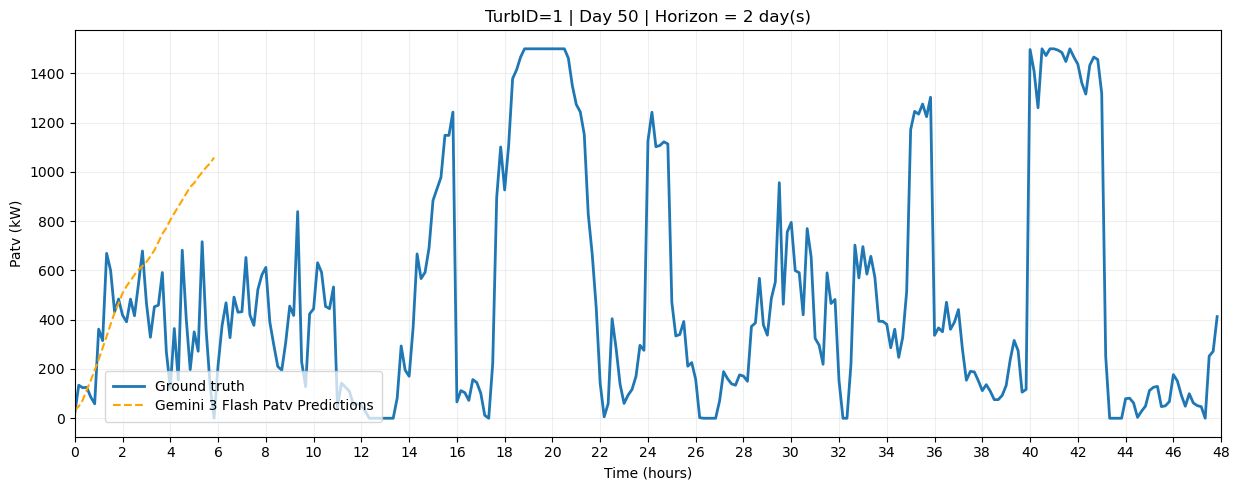

(<Figure size 1250x500 with 1 Axes>,
 <Axes: title={'center': 'TurbID=1 | Day 50 | Horizon = 2 day(s)'}, xlabel='Time (hours)', ylabel='Patv (kW)'>)

In [ ]:
plot_llm_predictions_vs_ground_truth(
    data_df=df, 
    llm_responses=[advanced_output], 
    labels=["Gemini 3 Flash Patv Predictions"],
    turb_id=Turbine, 
    forecast_day=Forecast_Day
)

# Finding Starting Date for Dataset (Aligning Dataset with Forecasts)

In [ ]:
import pandas as pd
import numpy as np

# 1. Prepare the KDD Data (Actuals)
df_actuals = df.copy()

# 2. Prepare the Weather Data (Forecasts)
latitude = 40.6306
longitude = 96.9498
start_date = datetime(2020, 1, 1)
end_date = datetime(2022, 1, 1)
hourly_dataframe = get_openmeteo_wind_data(latitude, longitude, start_date, end_date)
df_forecast = hourly_dataframe.copy()
df_forecast.rename(columns={'date': 'timestamp'}, inplace=True)


In [ ]:
import pandas as pd
import numpy as np

# 1. First, get the farm-wide average for every unique 10-minute slot
# This averages all 134 turbines together
farm_10min = df_actuals.groupby(['Day', 'Tmstamp']).mean(numeric_only=True).reset_index()

# 2. Ensure it is sorted chronologically
farm_10min = farm_10min.sort_values(by=['Day', 'Tmstamp'])

# 3. Create a grouping index that changes every 6 rows
# (0,0,0,0,0,0, 1,1,1,1,1,1, 2,2,2...)
n = 6
grouping_index = np.arange(len(farm_10min)) // n

# 4. Group by that index and calculate the mean
# We use .agg to keep the 'Day' and 'Tmstamp' labels from the start of each hour
hourly_timeline = farm_10min.groupby(grouping_index).agg({
    'Day': 'first',
    'Tmstamp': 'first',
    'Wspd': 'mean',
    'Wdir': 'mean',
    'Etmp': 'mean'
    # Add other columns here if needed
}).reset_index(drop=True)

print("--- Hourly Farm Averages (Every 6 Timestamps) ---")
print(hourly_timeline.head(10))

# Verification: 245 days * 24 hours = 5,880 rows
print(f"\nTotal Hourly Rows: {len(hourly_timeline)}")

--- Hourly Farm Averages (Every 6 Timestamps) ---
   Day Tmstamp       Wspd      Wdir       Etmp
0    1   00:00   5.468524 -5.302769  54.945236
1    1   01:00   4.961774 -4.764017  54.406771
2    1   02:00   5.395871 -4.531779  53.892587
3    1   03:00   5.608097 -3.787973  53.720261
4    1   04:00   7.361642 -1.734789  53.769851
5    1   05:00   6.956517 -3.950908  53.909900
6    1   06:00   9.359863 -2.609279  53.510249
7    1   07:00  11.617985  0.158197  52.953881
8    1   08:00  11.129535 -0.947709  52.671529
9    1   09:00  10.793706 -0.322512  54.733371

Total Hourly Rows: 5880


In [ ]:
import pandas as pd
import numpy as np

# 1. Clean the string column (remove spaces, handle NaNs)
df_actuals['Tmstamp'] = df_actuals['Tmstamp'].astype(str).str.strip()

# 2. Extract Hours and Minutes from the "HH:MM" string
# We split "00:10" into [00, 10]
time_parts = df_actuals['Tmstamp'].str.split(':', expand=True)
df_actuals['hours'] = pd.to_numeric(time_parts[0], errors='coerce')
df_actuals['mins'] = pd.to_numeric(time_parts[1], errors='coerce')

# 3. Build the True Timestamp
# Base Date (May 1) + (Day Index - 1) + Hours + Minutes
df_actuals['timestamp'] = pd.to_datetime("2020-05-01") + \
                          pd.to_timedelta(df_actuals['Day'] - 1, unit='D') + \
                          pd.to_timedelta(df_actuals['hours'], unit='h') + \
                          pd.to_timedelta(df_actuals['mins'], unit='m')

# 4. Cleanup and Drop the "Separator" rows (where time parsing failed)
df_actuals = df_actuals.dropna(subset=['timestamp', 'Wspd'])

# 5. Now Downsample to Hourly for comparison
df_actuals_hourly = df_actuals.groupby(['TurbID', pd.Grouper(key='timestamp', freq='1h')]).agg({
    'Wspd': 'mean',
    'Etmp': 'mean'
}).reset_index()


## Find correct start date by comparing forecast to actual and finding highest correlation across **14 days**

--- 14-Day Scan Results ---
Highest Correlation: 0.7781
Found Match Starting: 2020-05-01T02:00:00


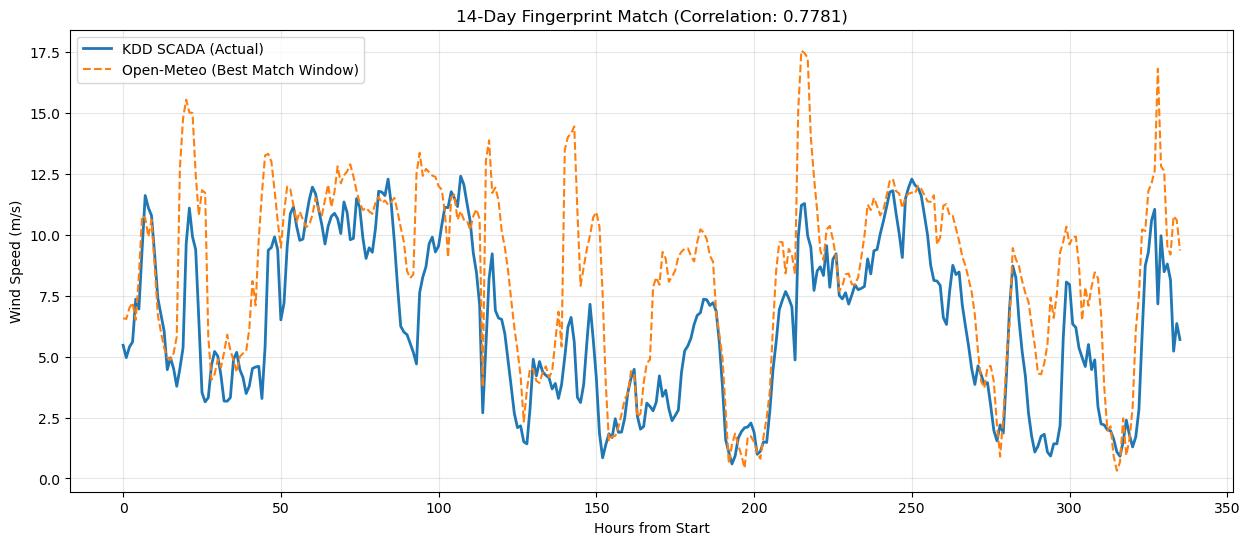

In [ ]:
import pandas as pd
import numpy as np

# 1. Prepare the "Signature" (First 7 days of KDD)
# We use the hourly averaged version we just built
signature_len = 24 * 14  # 1 week of hourly data
kdd_sig = df_actuals_hourly.groupby('timestamp')['Wspd'].mean().head(signature_len).values

# 2. Prepare the "Search Space" (Full 2-year Weather)
# Ensure weather_df is sorted and has no gaps
weather_search = df_forecast.sort_values('timestamp')['wind_speed_100m'].values
weather_times = df_forecast.sort_values('timestamp')['timestamp'].values

# 3. Sliding Window Search
correlations = []
# We slide the KDD signature across the weather data
for i in range(len(weather_search) - signature_len):
    window = weather_search[i : i + signature_len]
    # Calculate Correlation Coefficient
    corr = np.corrcoef(kdd_sig, window)[0, 1]
    correlations.append(corr)

# 4. Find the Best Match
best_idx = np.argmax(correlations)
best_score = correlations[best_idx]
best_start_date = weather_times[best_idx]

print(f"--- 14-Day Scan Results ---")
print(f"Highest Correlation: {best_score:.4f}")
print(f"Found Match Starting: {best_start_date}")

# 5. Visual Validation
# Let's plot the match to see if they actually look similar
best_window = weather_search[best_idx : best_idx + signature_len]

plt.figure(figsize=(15, 6))
plt.plot(range(signature_len), kdd_sig, label='KDD SCADA (Actual)', linewidth=2)
plt.plot(range(signature_len), best_window, label='Open-Meteo (Best Match Window)', linestyle='--')
plt.title(f"14-Day Fingerprint Match (Correlation: {best_score:.4f})")
plt.xlabel("Hours from Start")
plt.ylabel("Wind Speed (m/s)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

This start date matches those that we found online that place the start date of the KDD Cup anonymized dataset at 2020/02/01

# LLM API Call with Forecast added

In [ ]:
def call_llm_with_forecast(df, Turb_ID, base_day, forecast_on=False):
    turbine_data = df[df['TurbID'] == Turb_ID]
    turbine_data = turbine_data.dropna(subset=['Wspd'])

    # Keep 14 days of history
    end_day = base_day + 13
    forecast_day = end_day + 1  

    window_data = turbine_data[
        (turbine_data['Day'] >= base_day) & 
        (turbine_data['Day'] <= end_day)
    ].copy()

    print(f"📊 Binning data into 16 levels...")
    window_data, binned_list = bin_turbine_data(window_data, n_bins=16)
    bin_msg = f"Note: Numeric columns ({', '.join(binned_list)}) have been binned into 16 equal-width levels (0-15)."
    
    data_str = window_data.to_csv(index=False, sep=',')

    forecast_section = "No external meteorological forecast provided."

    if forecast_on:
        # latitude and longitude from: https://www.gem.wiki/Gansu_Guazhou_Qiaowan_Number_3_North_wind_farm
        latitude = 40.6306
        longitude = 96.9498
        anchor_date = datetime(2020, 5, 1)
        forecast_start_date = anchor_date + timedelta(days=int(base_day + 13))
        forecast_end_date = forecast_start_date + timedelta(days=2) # 48 hours later
        
        # Format for API: "YYYY-MM-DD"
        start_str = forecast_start_date.strftime('%Y-%m-%d')
        end_str = forecast_end_date.strftime('%Y-%m-%d')

        MAX_ATTEMPTS = 3

        for attempt in range(1, MAX_ATTEMPTS + 1):
            try:
                print(f"🌐 Forecast Tool: Fetching weather for {start_str} to {end_str}...")
                weather_df = get_openmeteo_wind_data(latitude, longitude, start_str, end_str)
                
                # Slice to exactly 48 hours and interpolate to 10-minute intervals
                # 48 hourly points -> 288 ten-minute points
                w_speeds = weather_df['wind_speed_100m'].values[:48]
                xp = np.arange(len(w_speeds))
                x_new = np.linspace(0, len(w_speeds)-1, 288)
                interp_w_speeds = np.interp(x_new, xp, w_speeds)
                
                forecast_str = ", ".join([f"{v:.2f}" for v in interp_w_speeds])
                forecast_section = f"""Input 2: 48-Hour Meteorological Forecast (100m)
    Predicted wind speeds (m/s) at 10-minute intervals for the next 48 hours:
    [{forecast_str}]"""
                print("✅ Data successfully retrieved!")
                break 
            except Exception as e:
                print(f"⚠️ Attempt {attempt} failed: {e}")
                if attempt < MAX_ATTEMPTS:
                    print("Retrying in 5 seconds...")
                    time.sleep(5)
                else:
                    print("❌ All 3 attempts failed. Proceeding with SCADA only.")

    prompt = f"""
    Context: You are an expert wind turbine power forecasting model.

    {bin_msg}

    Input 1: You are given 14 days of historical SCADA data for ONE turbine.
    The data is sampled every 10 minutes (144 rows per day).
    Columns provided: {', '.join(window_data.columns.tolist())}
    {data_str}

    {forecast_section}

    Your task:
    Predict the Active Power (Patv, in kW) for the NEXT 48 HOURS
    (288 time steps at 10-minute resolution).

    Instructions:

    Learn the wind-speed to power relationship from the historical data.
    Power is roughly proportional to wind speed cubed at low speeds.
    Power saturates near rated power (~1500 kW).
    Power is near zero at very low wind speeds.

    Capture daily cyclic patterns.
    Do NOT copy the last day.
    Do NOT output negative values.
    Clip values to the realistic range [0, 1500].

    OUTPUT FORMAT REQUIREMENTS (CRITICAL):

    Return valid JSON in the following format:

    {{
    "forecast": [f1, f2, f3, ..., f288]
    }}

    The list MUST contain exactly 288 numbers.
    If the list contains more or fewer values, the answer is invalid.

    No text outside the JSON.
    No explanations.
    No markdown formatting.
    Only raw JSON.
    """

    if PROVIDER == "claude":
        response = client.messages.create(
            model="claude-3-haiku-20240307",
            max_tokens=1024,
            messages=[{"role": "user", "content": prompt}]
        )
        output= response.content[0].text
    else:  # gemini
        response = client.generate_content(
            prompt
        )
        output= response.text
    
    print("LLM Response:")
    print(output)
    eval_results = evaluate_llm_forecast_48h(df, Turb_ID, base_day, output)

    plot_llm_predictions_vs_ground_truth(
        data_df=df, 
        llm_responses=[output], 
        labels=["Gemini 3 Flash Patv Predictions"],
        turb_id=Turb_ID, 
        forecast_day=forecast_day
    )


In [67]:
# Select from Turbines ID 1 - 134
Turbine = 1

# Select from Days 1 - 231 (There are 245 days total, but we need to leave room for the 14-day input window and 2-day forecast horizon)
Data_Start_Day = 1

# Decide which features to use for the LLM forecast
Used_Columns = feature_sets["all_features"]

# Used when plotting to indicate forecast start day on x-axis
Forecast_Day = Data_Start_Day + 14

📊 Binning data into 16 levels...
🌐 Agent Tool: Fetching weather for 2020-05-15 to 2020-05-17...
✅ Data successfully retrieved!
LLM Response:
{
"forecast": [1400, 1300, 1300, 1200, 1200, 1200, 1100, 1100, 1000, 1000, 900, 800, 800, 800, 800, 900, 900, 1000, 1000, 1000, 900, 900, 800, 700, 700, 600, 600, 600, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 600, 600, 600, 700, 700, 800, 800, 800, 700, 700, 700, 700, 600, 600, 700, 700, 700, 700, 800, 800, 900, 1000, 1000, 1100, 1100, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1000, 1000, 1000, 1000, 1000, 900, 900, 900, 900, 900, 900, 900, 900, 900, 800, 800, 800, 800, 800, 800, 900, 900, 1000, 1000, 900, 900, 900, 800, 800, 800, 700, 700, 700, 600, 600, 500, 500, 500, 400, 400, 400, 400, 400, 400, 40

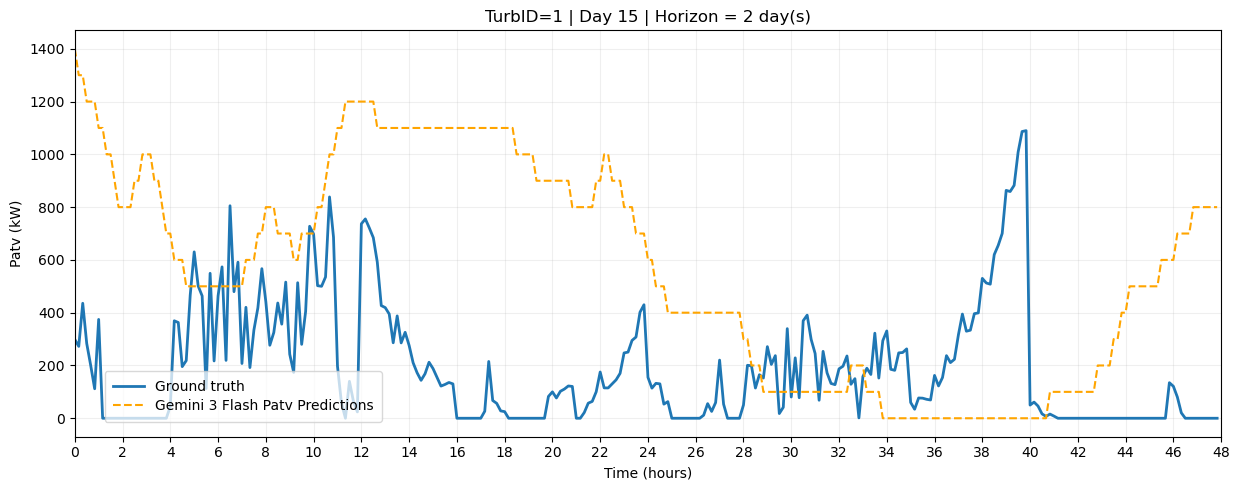

In [71]:
call_llm_with_forecast(df, Turb_ID=Turbine, base_day=Data_Start_Day, forecast_on=True)